In [1]:
import os 
os.environ['JAX_JIT_PJIT_API_MERGE'] = '0'
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'gpu')
from qiskit_dynamics.array import Array
Array.set_default_backend('jax')

/home/jiakai/.local/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(


# Define undriven system using scqubits, then convert to qiskit

Progress: Chunk 129/129 solved.


 /home/jiakai/.local/lib/python3.10/site-packages/jax/_src/array.py: 363

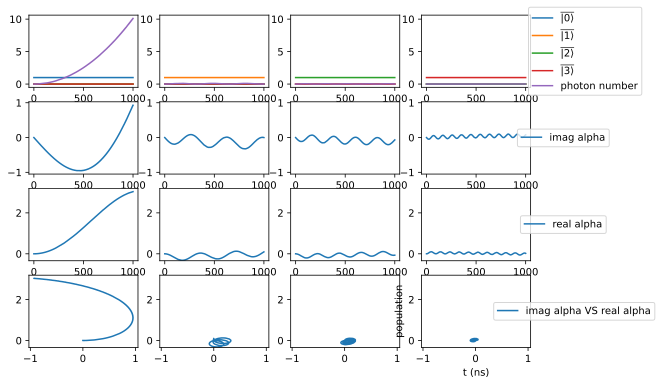

In [2]:
from utils import *
import numpy as np
from qiskit.quantum_info import Operator
from qiskit_dynamics import Solver
import jax.numpy as jnp
from qiskit import pulse

EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3
E_osc = 3
qubit_level = 8
osc_level =50


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
# plot_specturum(qbt, osc, hilbertspace)





def qobj_to_Array(matrix):
    if type(matrix) == qutip.qobj.Qobj:
        matrix = matrix.full()
    # return Operator(matrix, input_dims = (matrix.shape[0],),output_dims = (matrix.shape[1],))
    return Array(matrix)

(evals,) = hilbertspace["evals"]
diag_matrix = np.diag(evals)
static_hamiltonian = 2 * np.pi * qobj_to_Array(diag_matrix)



leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]

a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)


tot_dims = a.shape[0]
g0 = jnp.zeros(tot_dims).at[product_to_dressed[(0, 0)]].set(1).reshape(-1, 1)
e0 = jnp.zeros(tot_dims).at[product_to_dressed[(1, 0)]].set(1).reshape(-1, 1)
f0 = jnp.zeros(tot_dims).at[product_to_dressed[(2, 0)]].set(1).reshape(-1, 1)
h0 = jnp.zeros(tot_dims).at[product_to_dressed[(3, 0)]].set(1).reshape(-1, 1)


tot_time = 1000
tlist =  np.linspace(0,tot_time, int(tot_time)*5)

base_drive_amplitude = 0.002 * 2 * np.pi

# from qiskit_dynamics.pulse import InstructionToSignals
# converter = InstructionToSignals(signal_sample_dt, carriers={"d0": w_d})
# signals = converter.get_signals(square)
# fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))
# for ax, title in zip(axs, ["envelope", "signal"]):
#     signals[0].draw(0, tot_time/2000, 2000, title, axis=ax)
#     ax.set_xlabel("Time (ns)")
#     ax.set_ylabel("Amplitude")
#     ax.set_title(title)


w_d = abs(transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 ))

signal_sample_dt = 0.001 
driven_operator =  qobj_to_Array(a+a.dag())

with pulse.build(name="square") as square:
    pulse.play(pulse.Constant(duration = int(tot_time/signal_sample_dt), amp = base_drive_amplitude), pulse.DriveChannel(0))

# square.draw()

ham_solver =  Solver(
                hamiltonian_operators=[driven_operator],
                static_hamiltonian=static_hamiltonian,
                hamiltonian_channels=['d0'],
                channel_carrier_freqs={'d0': w_d},
                dt=signal_sample_dt
            )

ham_solver.model.evaluation_mode = "dense"

results = []
for psi0 in [g0,e0,f0,h0]:
    result =solve_with_jax_gpu(ham_solver=ham_solver,
                    y0=psi0,
                    tlist=tlist,
                    signals=square,
                    chunk_size=40
                )

    # result =ham_solver.solve(
    #             y0=psi0,
    #             t_span=[0, tot_time],
    #             signals=square,
    #             method='jax_odeint',
    #             t_eval = tlist,
    #             atol=1e-8,
    #             rtol=1e-8
    #         )
    results.append(result)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)